In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n0 = 5                                                
n1 = 8                                                   
n2 = 11
N0 = 2**n0                                              
N1 = 2**n1
N2 = 2**n2
n_reduce = 4                                          
N_reduce = 2**n_reduce                                  
t = 5                                                   
dt = 0.01                                               
steps = int(t/dt) + 1                                  
x_max = 10                                              
x0_grid = np.linspace(-x_max, x_max, N0, endpoint=False)
x1_grid = np.linspace(-x_max, x_max, N1, endpoint=False)
x2_grid = np.linspace(-x_max, x_max, N2, endpoint=False)

dx0 = x0_grid[1] - x0_grid[0]                           
dx1 = x1_grid[1] - x1_grid[0]
dx2 = x2_grid[1] - x2_grid[0]

freq0 = np.fft.fftfreq(N0, dx0)                         
freq1 = np.fft.fftfreq(N1, dx1)
freq2 = np.fft.fftfreq(N2, dx2)
k0 = 2 * np.pi * freq0                                  
k1 = 2 * np.pi * freq1                                    
k2 = 2 * np.pi * freq2                                     
L_half0 = np.exp(-1j * k0**2 * dt/4)                    
L_half1 = np.exp(-1j * k1**2 * dt/4)
L_half2 = np.exp(-1j * k2**2 * dt/4)

In [ ]:

def initial_state_soliton(x, beta=0.5, xc=0.0, v=2.0):
    profile = 1.0 / np.cosh(beta * (x - xc))


    A = 1.0 / np.linalg.norm(profile)

    psi = A * profile * np.exp(1j *0.5 * v * (x - xc))

    g = - beta**2 / A**2

    return psi, g, A

In [ ]:

def ssfm(psi, g, dt, k, L_half):
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         
    psi = psi*np.exp(-g*1j * np.abs(psi)**2 * dt)       
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         

    return psi

In [ ]:

def filtering(modes, N, N_reduce):

    half = N_reduce // 2
    filtered_modes = np.zeros(N , dtype=complex)
    filtered_modes[:half] = modes[:half]         
    filtered_modes[-half:] = modes[-half:]        

    return filtered_modes

In [ ]:

def filtered_ssfm(psi, g, dt, k, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                      
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)

    psi *= np.exp(-g* 1j * np.abs(psi)**2 * dt)        

    psi = np.fft.fft(psi) * L_half                     
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)
    return psi

In [ ]:

def filtered_qssfm(psi, g, dt, k, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                               
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)

    nonlinear_term = np.fft.ifft(modes)
    psi *= np.exp(-g* 1j * np.abs(nonlinear_term)**2 * dt)         

    psi = np.fft.fft(psi) * L_half                               
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)
    return psi

In [ ]:

def percent_k(psi_ssfm, psi_qssfm, N, N_reduce):
    a = np.fft.fft(psi_ssfm)
    b = np.fft.fft(psi_qssfm) 
    b = filtering(b, N, N_reduce)
    eta = np.sum(np.abs(b)**2) / np.sum(np.abs(a)**2)
    
    return eta

In [ ]:

def error(psi, psi_exact):
    rho_exact = np.abs(psi_exact)**2
    rho1 = np.abs(psi)**2
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:

if __name__ == "__main__":



    psi0, g0, A0 = initial_state_soliton(x0_grid, beta=0.5, xc=0.0, v=2.0)
    psi1, g1, A1 = initial_state_soliton(x1_grid, beta=0.5, xc=0.0, v=2.0)
    psi2, g2, A2 = initial_state_soliton(x2_grid, beta=0.5, xc=0.0, v=2.0)

    psi0density_history = [np.abs(psi0)**2/A0**2]                    
    psi1density_history = [np.abs(psi1)**2/A1**2]                    
    psi2density_history = [np.abs(psi2)**2/A2**2]                    
    psi_exact0 = np.copy(psi0)
    psi_exact1 = np.copy(psi1)
    psi_exact2 = np.copy(psi2)
    psi_exact0density_history = [np.abs(psi_exact0)**2/A0**2]
    psi_exact1density_history = [np.abs(psi_exact1)**2/A1**2]
    psi_exact2density_history = [np.abs(psi_exact2)**2/A2**2]
    times = [0]                                  
    error_history0 = [error(psi0/A0, psi_exact0/A0)]                                                                                 
    error_history1 = [error(psi1/A1, psi_exact1/A1)]                                                                                
    error_history2 = [error(psi2/A2, psi_exact2/A2)] 
    etan5 = [percent_k(psi_exact0, psi0, N0, N_reduce)]
    etan8 = [percent_k(psi_exact1, psi1, N1, N_reduce)]  
    etan11 = [percent_k(psi_exact2, psi2, N2, N_reduce)]

    for i in range(steps):
        psi_exact0 = ssfm(psi_exact0, g0, dt, k0, L_half0)
        psi_exact1 = ssfm(psi_exact1, g1, dt, k1, L_half1)
        psi_exact2 = ssfm(psi_exact2, g2, dt, k2, L_half2)

        psi0 = filtered_qssfm(psi0, g0, dt, k0, L_half0, N0, N_reduce)
        psi1 = filtered_qssfm(psi1, g1, dt, k1, L_half1, N1, N_reduce)
        psi2 = filtered_qssfm(psi2, g2 , dt, k2, L_half2, N2, N_reduce)

        times.append((i + 1)*dt)                            
        psi0density_history.append(np.abs(psi0)**2/A0**2)   
        psi1density_history.append(np.abs(psi1)**2/A1**2)  
        psi2density_history.append(np.abs(psi2)**2/A2**2)   
        psi_exact0density_history.append(np.abs(psi_exact0)**2/A0**2)                                         
        psi_exact1density_history.append(np.abs(psi_exact1)**2/A1**2)                                         
        psi_exact2density_history.append(np.abs(psi_exact2)**2/A2**2)                                           
        error_history0.append(error(psi0, psi_exact0))                                                
        error_history1.append(error(psi1, psi_exact1))                                                 
        error_history2.append(error(psi2, psi_exact2))                                                   
        etan5.append(percent_k(psi_exact0, psi0, N0, N_reduce))
        etan8.append(percent_k(psi_exact1, psi1, N1, N_reduce))
        etan11.append(percent_k(psi_exact2, psi2, N2, N_reduce))


    np.savez(f"1d-n-effect.npz",    
            times=times,
            psi_n5=psi0density_history,
            psi_n8=psi1density_history,
            psi_n11=psi2density_history,
            psi_exact_n5=psi_exact0density_history,
            psi_exact_n8=psi_exact1density_history,
            psi_exact_n11=psi_exact2density_history,
            rel_l2_err_n5=error_history0,
            rel_l2_err_n8=error_history1,
            rel_l2_err_n11=error_history2,            
            etan5 = etan5,
            etan8 = etan8,
            etan11 = etan11,
            ) 

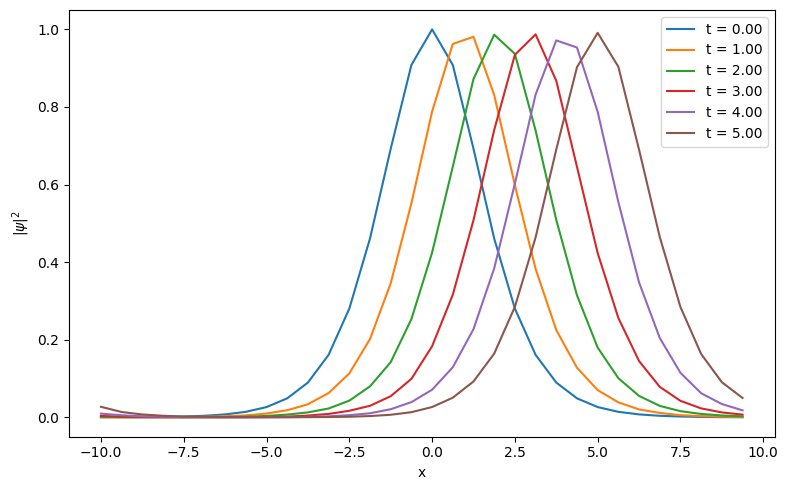

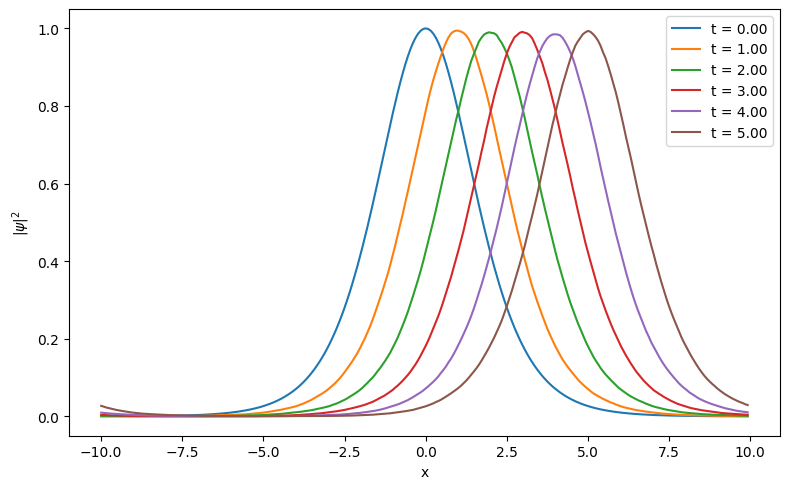

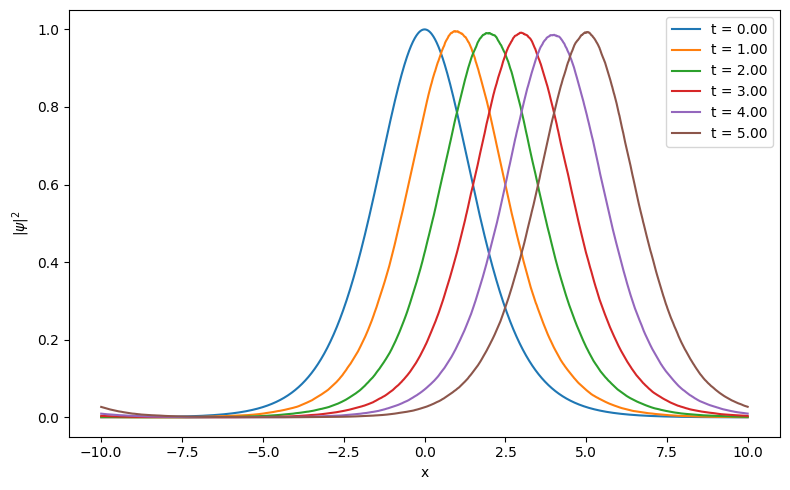

In [ ]:
plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x0_grid, psi0density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()

plt.show()


plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x1_grid, psi1density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x2_grid, psi2density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()

plt.show()




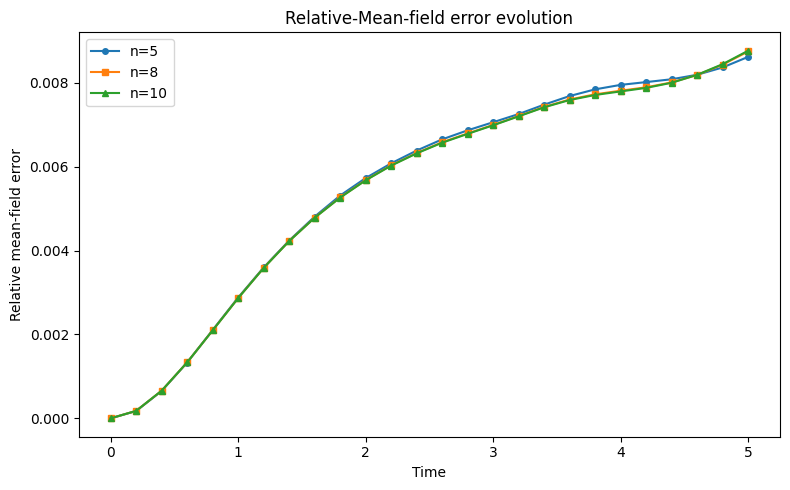

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times[::20], error_history0[::20], label='n=5',marker='o', markersize=4)
plt.plot(times[::20], error_history1[::20], label='n=8',marker='s', markersize=4)
plt.plot(times[::20], error_history2[::20], label='n=10',marker='^', markersize=4)


plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()

plt.show()